# Install

In [1]:
!pip install datasets torch torchvision matplotlib numpy pillow seaborn pandas -q

# Clone repo & set path

In [2]:
!git clone https://github.com/AAnanya19/Human-Faces-Generation-Diffusion-Models.git 2>/dev/null || echo "Repo already cloned"

import sys
sys.path.insert(0, '/content/Human-Faces-Generation-Diffusion-Models/')
print("Path set.")
# print("Using locally uploaded dataloader.py")

Path set.


# Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
from datasets import load_dataset
import os
import warnings
warnings.filterwarnings('ignore')

from data.dataloader import create_dataloaders, splits, get_transforms, ButterflyDataset

# # --- TEMPORARY: importing from uploaded runtime file ---
# # import sys
# # sys.path.insert(0, '/content/Human-Faces-Generation-Diffusion-Models/src')
# # from data.dataloader import create_dataloaders, splits, get_transforms, ButterflyDataset
# import importlib.util, sys
# spec = importlib.util.spec_from_file_location("dataloader", "/content/dataloader.py")
# # Fix: Replaced load_from_spec with module_from_spec and exec_module
# dataloader_module = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(dataloader_module)
# create_dataloaders = dataloader_module.create_dataloaders
# splits = dataloader_module.splits
# get_transforms = dataloader_module.get_transforms
# ButterflyDataset = dataloader_module.ButterflyDataset
# # --- TEMPORARY ---

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})
COLOURS = {'R': '#e74c3c', 'G': '#2ecc71', 'B': '#3498db', 'Gray': '#7f8c8d'}
print("All imports successful.")

All imports successful.


# Load splits & Fig 1: Split overview

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 800 | Val: 100 | Test: 100 | Total: 1000


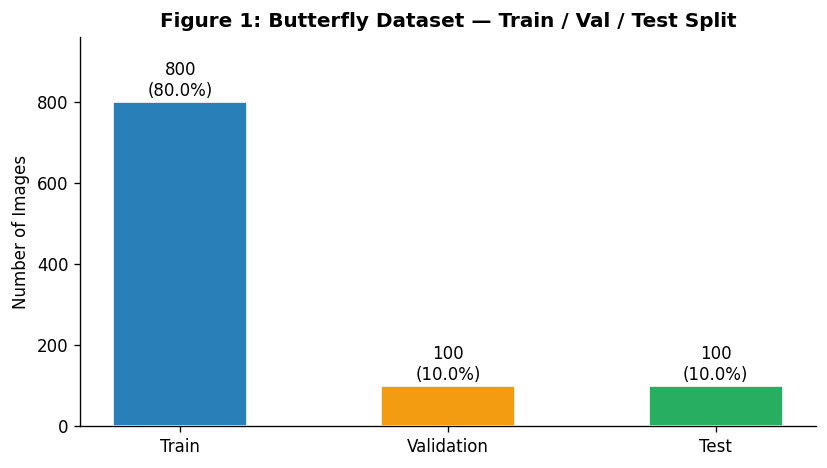

In [4]:
train_data, val_data, test_data = splits(seed=42)
total = len(train_data) + len(val_data) + len(test_data)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)} | Total: {total}")

fig, ax = plt.subplots(figsize=(7, 4))
split_names = ['Train', 'Validation', 'Test']
split_sizes = [len(train_data), len(val_data), len(test_data)]
bars = ax.bar(split_names, split_sizes, color=['#2980b9','#f39c12','#27ae60'], edgecolor='white', width=0.5)
for bar, size in zip(bars, split_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{size}\n({size/total*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title("Figure 1: Butterfly Dataset — Train / Val / Test Split", fontweight='bold')
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(split_sizes) * 1.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("fig1_split_overview.png", bbox_inches='tight', dpi=150)
plt.show()

# Fig 2: Raw sample grid

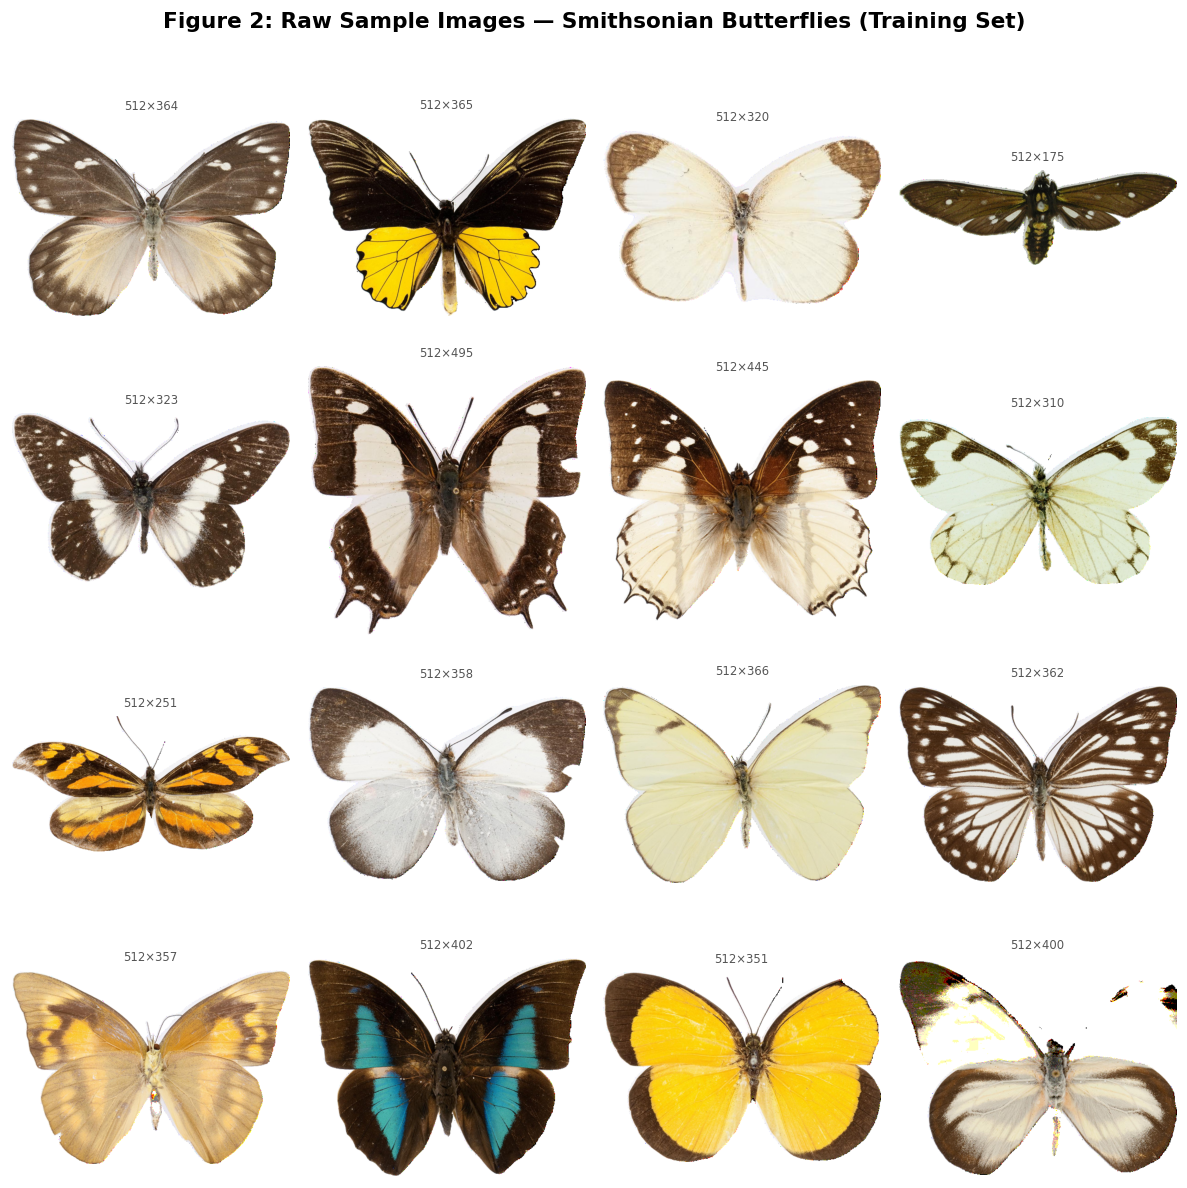

In [5]:
np.random.seed(42)
indices = np.random.choice(len(train_data), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Figure 2: Raw Sample Images — Smithsonian Butterflies (Training Set)",
             fontsize=13, fontweight='bold', y=1.01)
for ax, idx in zip(axes.flatten(), indices):
    img = train_data[int(idx)]['image'].convert('RGB')
    w, h = img.size
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"{w}×{h}", fontsize=7, color='#555')
plt.tight_layout()
plt.savefig("fig2_raw_sample_grid.png", bbox_inches='tight', dpi=150)
plt.show()

# Load dataloader & Fig 3: Preprocessed grid

Repo card metadata block was not found. Setting CardData to empty.


Batch shape: torch.Size([16, 3, 128, 128])
Pixel min: -1.0000 | max: 1.0000


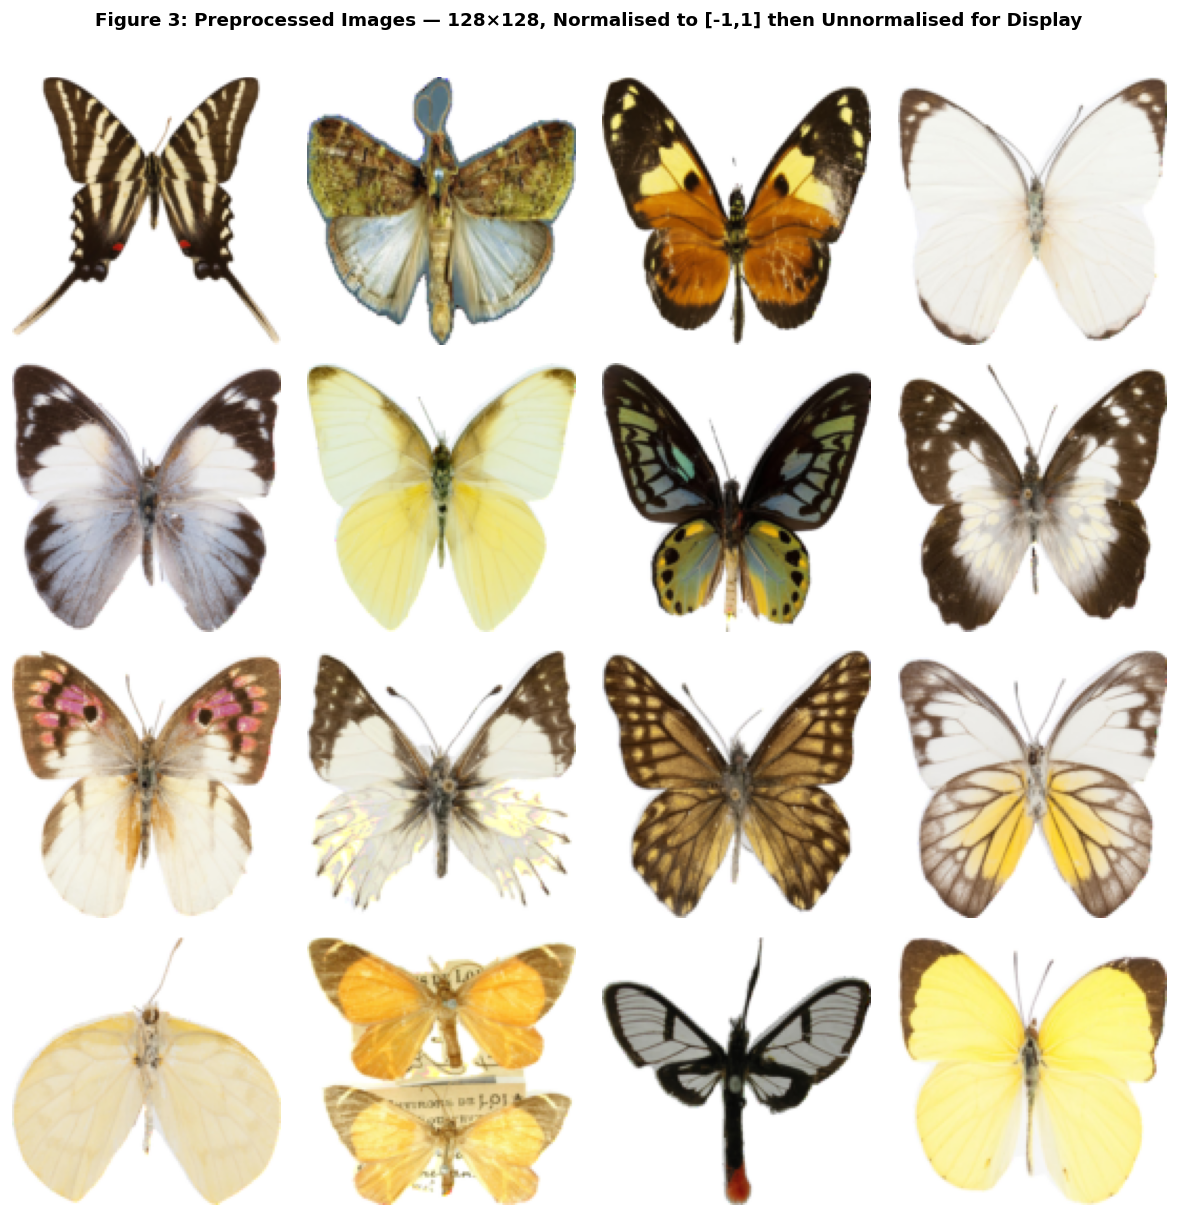

In [6]:
IMAGE_SIZE = 128
train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=16, image_size=IMAGE_SIZE, seed=42, num_workers=0)

batch = next(iter(train_loader)) #tensor size 16 x 3 x 128 x 128
print(f"Batch shape: {batch.shape}")
print(f"Pixel min: {batch.min().item():.4f} | max: {batch.max().item():.4f}")

def unnormalise(tensor):
    return (tensor * 0.5) + 0.5

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Figure 3: Preprocessed Images — 128×128, Normalised to [-1,1] then Unnormalised for Display",
             fontsize=11, fontweight='bold', y=1.01)
for i, ax in enumerate(axes.flatten()):
    img_display = unnormalise(batch[i]).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_display.numpy()); ax.axis('off')
plt.tight_layout()
plt.savefig("fig3_preprocessed_grid.png", bbox_inches='tight', dpi=150)
plt.show()

# Pixel stats (raw)

In [7]:
SAMPLE_N = 200
TARGET_SIZE = (128, 128)
np.random.seed(42)
sample_idx = np.random.choice(len(train_data), SAMPLE_N, replace=False)

r_vals, g_vals, b_vals = [], [], []
widths_raw, heights_raw = [], []

for idx in sample_idx:
    img = train_data[int(idx)]['image'].convert('RGB')
    w, h = img.size
    widths_raw.append(w); heights_raw.append(h)
    arr = np.array(img.resize(TARGET_SIZE)) / 255.0
    r_vals.append(arr[:,:,0].flatten())
    g_vals.append(arr[:,:,1].flatten())
    b_vals.append(arr[:,:,2].flatten())

r_vals = np.concatenate(r_vals)
g_vals = np.concatenate(g_vals)
b_vals = np.concatenate(b_vals)
widths_raw = np.array(widths_raw)
heights_raw = np.array(heights_raw)

print(f"Width  — min:{widths_raw.min()} max:{widths_raw.max()} mean:{widths_raw.mean():.1f}")
print(f"Height — min:{heights_raw.min()} max:{heights_raw.max()} mean:{heights_raw.mean():.1f}")
print(f"R  μ={r_vals.mean():.4f} σ={r_vals.std():.4f}")
print(f"G  μ={g_vals.mean():.4f} σ={g_vals.std():.4f}")
print(f"B  μ={b_vals.mean():.4f} σ={b_vals.std():.4f}")

Width  — min:192 max:512 mean:509.9
Height — min:175 max:512 mean:368.5
R  μ=0.7674 σ=0.2932
G  μ=0.7207 σ=0.3198
B  μ=0.6312 σ=0.3644


# Fig 4: Dimension distributions

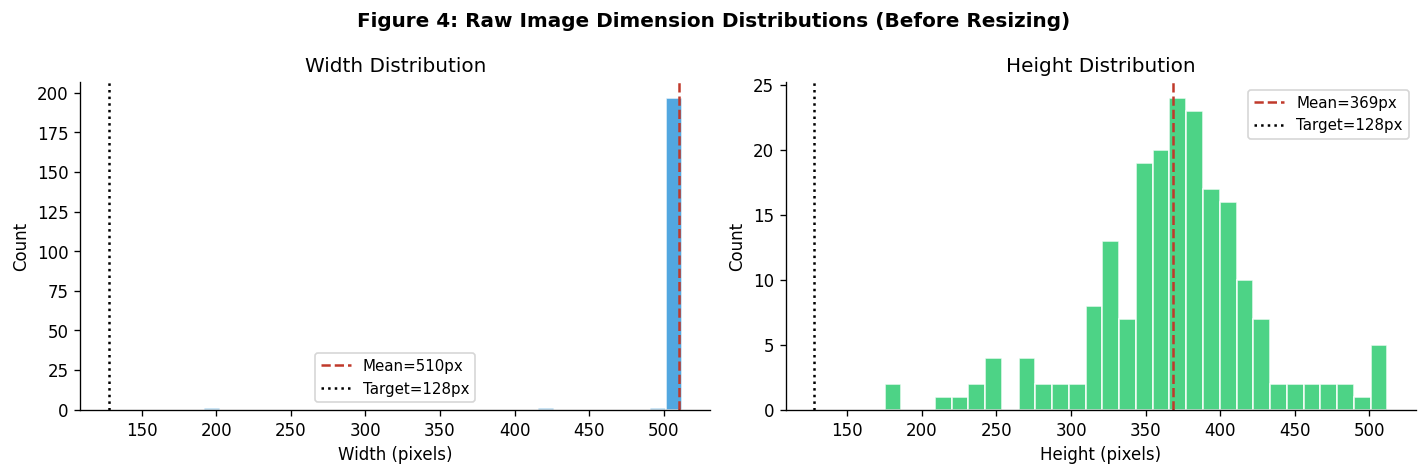

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figure 4: Raw Image Dimension Distributions (Before Resizing)", fontweight='bold')
for ax, vals, label, colour in [
    (axes[0], widths_raw,  "Width (pixels)",  '#3498db'),
    (axes[1], heights_raw, "Height (pixels)", '#2ecc71')
]:
    ax.hist(vals, bins=30, color=colour, edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='#c0392b', linestyle='--', linewidth=1.5, label=f"Mean={vals.mean():.0f}px")
    ax.axvline(128, color='black', linestyle=':', linewidth=1.5, label="Target=128px")
    ax.set_xlabel(label); ax.set_ylabel("Count"); ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[0].set_title("Width Distribution")
axes[1].set_title("Height Distribution")
plt.tight_layout()
plt.savefig("fig4_dimension_distributions.png", bbox_inches='tight', dpi=150)
plt.show()

# Fig 5 & 6: Channel distributions (raw + normalised)

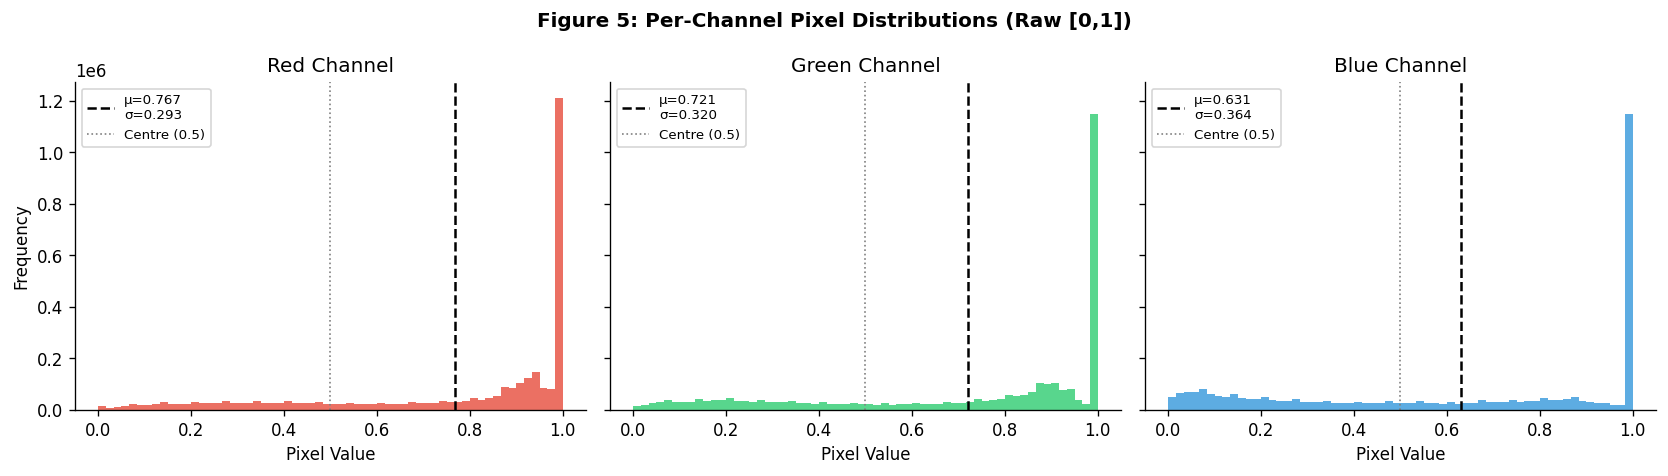

Repo card metadata block was not found. Setting CardData to empty.


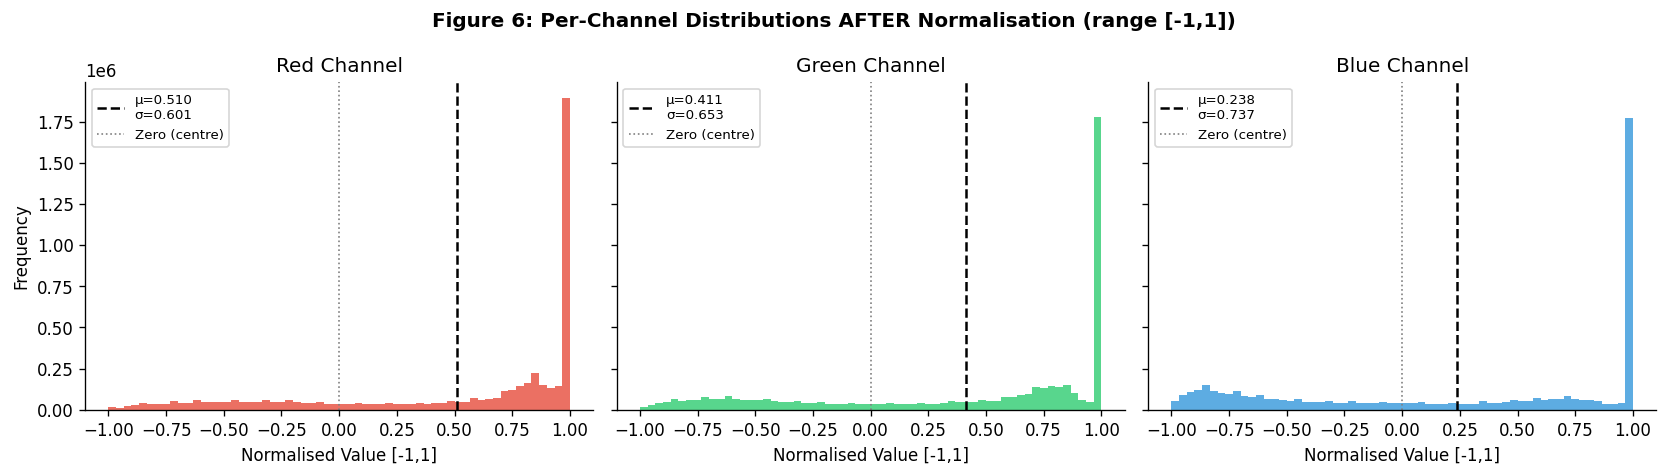

In [9]:
# Fig 5 — Raw
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Figure 5: Per-Channel Pixel Distributions (Raw [0,1])", fontweight='bold')
for ax, (name, vals, colour) in zip(axes, [('Red',r_vals,COLOURS['R']),('Green',g_vals,COLOURS['G']),('Blue',b_vals,COLOURS['B'])]):
    ax.hist(vals, bins=60, color=colour, alpha=0.8, edgecolor='none')
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5, label=f"μ={vals.mean():.3f}\nσ={vals.std():.3f}")
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, label="Centre (0.5)")
    ax.set_title(f"{name} Channel"); ax.set_xlabel("Pixel Value")
    if name=='Red': ax.set_ylabel("Frequency")
    ax.legend(fontsize=8); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_channel_distributions.png", bbox_inches='tight', dpi=150)
plt.show()

# Fig 6 — After normalisation
all_r, all_g, all_b = [], [], []
big_loader, _, _ = create_dataloaders(batch_size=64, image_size=IMAGE_SIZE, seed=42, num_workers=0)
for i, bt in enumerate(big_loader):
    all_r.append(bt[:,0,:,:].flatten().numpy())
    all_g.append(bt[:,1,:,:].flatten().numpy())
    all_b.append(bt[:,2,:,:].flatten().numpy())
    if i >= 4: break
norm_r, norm_g, norm_b = np.concatenate(all_r), np.concatenate(all_g), np.concatenate(all_b)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Figure 6: Per-Channel Distributions AFTER Normalisation (range [-1,1])", fontweight='bold')
for ax, (name, vals, colour) in zip(axes, [('Red',norm_r,COLOURS['R']),('Green',norm_g,COLOURS['G']),('Blue',norm_b,COLOURS['B'])]):
    ax.hist(vals, bins=60, color=colour, alpha=0.8, edgecolor='none')
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5, label=f"μ={vals.mean():.3f}\nσ={vals.std():.3f}")
    ax.axvline(0, color='gray', linestyle=':', linewidth=1, label="Zero (centre)")
    ax.set_title(f"{name} Channel"); ax.set_xlabel("Normalised Value [-1,1]")
    if name=='Red': ax.set_ylabel("Frequency")
    ax.legend(fontsize=8); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("fig6_normalised_distributions.png", bbox_inches='tight', dpi=150)
plt.show()

# Fig 7: Brightness & channel balance

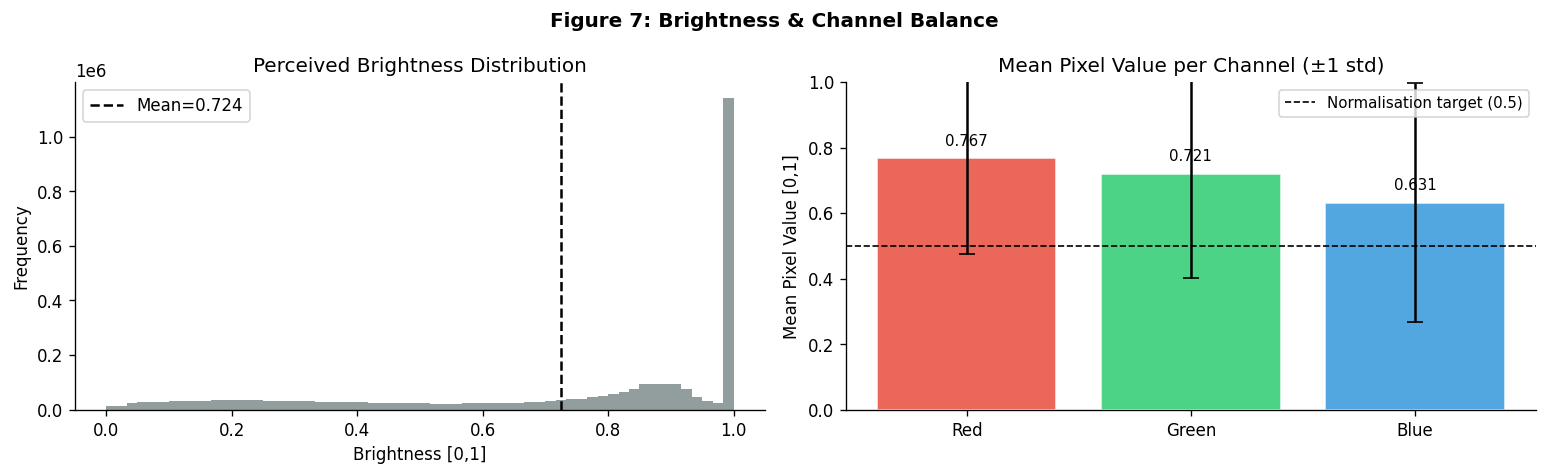

In [10]:
brightness = 0.299*r_vals + 0.587*g_vals + 0.114*b_vals

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Figure 7: Brightness & Channel Balance", fontweight='bold')

axes[0].hist(brightness, bins=60, color=COLOURS['Gray'], edgecolor='none', alpha=0.85)
axes[0].axvline(brightness.mean(), color='black', linestyle='--', linewidth=1.5, label=f"Mean={brightness.mean():.3f}")
axes[0].set_title("Perceived Brightness Distribution"); axes[0].set_xlabel("Brightness [0,1]"); axes[0].set_ylabel("Frequency")
axes[0].legend(); axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

channel_means = [r_vals.mean(), g_vals.mean(), b_vals.mean()]
channel_stds  = [r_vals.std(),  g_vals.std(),  b_vals.std()]
bars = axes[1].bar(['Red','Green','Blue'], channel_means, color=[COLOURS['R'],COLOURS['G'],COLOURS['B']],
                    edgecolor='white', yerr=channel_stds, capsize=5, alpha=0.85)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label="Normalisation target (0.5)")
axes[1].set_title("Mean Pixel Value per Channel (±1 std)"); axes[1].set_ylabel("Mean Pixel Value [0,1]")
axes[1].set_ylim(0, 1.0); axes[1].legend(fontsize=9)
for bar, mean in zip(bars, channel_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04, f"{mean:.3f}", ha='center', fontsize=9)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("fig7_brightness_channel_balance.png", bbox_inches='tight', dpi=150)
plt.show()

# Fig 8: Mean & std image

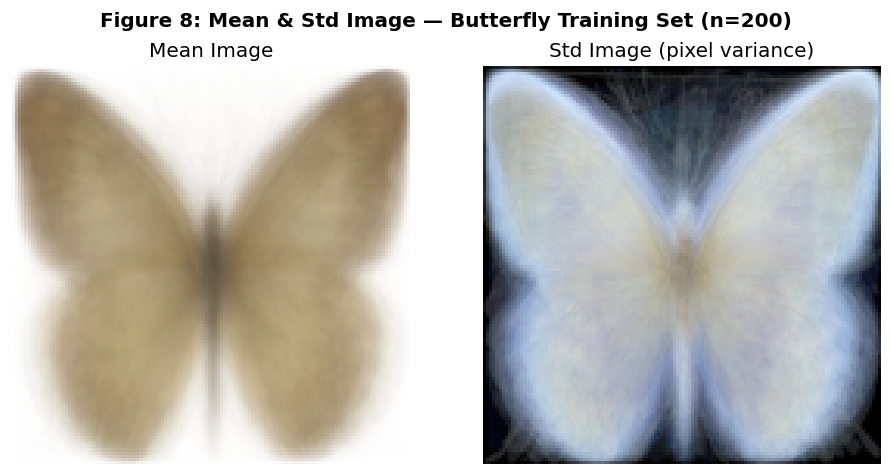

Bright areas in std image = high variation across images (diverse content).


In [11]:
stacked = []
for idx in sample_idx:
    img = train_data[int(idx)]['image'].convert('RGB').resize(TARGET_SIZE)
    stacked.append(np.array(img) / 255.0)

mean_img = np.mean(stacked, axis=0)
std_img  = np.std(stacked, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Figure 8: Mean & Std Image — Butterfly Training Set (n=200)", fontweight='bold')
axes[0].imshow(mean_img); axes[0].axis('off'); axes[0].set_title("Mean Image")
axes[1].imshow(std_img / std_img.max(), cmap='hot'); axes[1].axis('off'); axes[1].set_title("Std Image (pixel variance)")
plt.tight_layout()
plt.savefig("fig8_mean_std_image.png", bbox_inches='tight', dpi=150)
plt.show()
print("Bright areas in std image = high variation across images (diverse content).")

# Summary Table

In [12]:
import pandas as pd

summary = {
    'Property': [
        'Total images',
        'Train / Val / Test split',
        'Raw width (min / max / mean)',
        'Raw height (min / max / mean)',
        'Training input size',
        'Normalisation',
        'R channel mean (μ)',
        'G channel mean (μ)',
        'B channel mean (μ)',
        'R channel std (σ)',
        'G channel std (σ)',
        'B channel std (σ)',
        'Mean brightness',
        'Image mode',
    ],
    'Butterfly Dataset': [
        len(train_data) + len(val_data) + len(test_data),
        f"{len(train_data)} / {len(val_data)} / {len(test_data)}",
        f"{widths_raw.min()} / {widths_raw.max()} / {widths_raw.mean():.1f}px",
        f"{heights_raw.min()} / {heights_raw.max()} / {heights_raw.mean():.1f}px",
        '128×128 px',
        'mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5] → [-1,1]',
        f"{r_vals.mean():.4f}",
        f"{g_vals.mean():.4f}",
        f"{b_vals.mean():.4f}",
        f"{r_vals.std():.4f}",
        f"{g_vals.std():.4f}",
        f"{b_vals.std():.4f}",
        f"{brightness.mean():.4f}",
        'RGB',
    ],
    'CelebA-HQ Dataset': [
        '30,000',
        '2,700 / — / 300',
        '256 / 256 / 256px',
        '256 / 256 / 256px',
        '256×256 px (or 128×128)',
        'mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5] → [-1,1]',
        'TBC', 'TBC', 'TBC',
        'TBC', 'TBC', 'TBC',
        'TBC',
        'RGB (JPG)',
    ]
}

df = pd.DataFrame(summary)
df = df.set_index('Property')

# Display nicely in Colab
from IPython.display import display
display(df)

# Save for report reference
df.to_csv("dataset_summary_table.csv")
print("Saved: dataset_summary_table.csv")

,Butterfly Dataset,CelebA-HQ Dataset
Property,,
Total images,1000,"30,000"
Train / Val / Test split,800 / 100 / 100,"2,700 / — / 300"
Raw width (min / max / mean),192 / 512 / 509.9px,256 / 256 / 256px
Raw height (min / max / mean),175 / 512 / 368.5px,256 / 256 / 256px
Training input size,128×128 px,256×256 px (or 128×128)
Normalisation,"mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5] → [-1,1]","mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5] → [-1,1]"
R channel mean (μ),0.7674,TBC
G channel mean (μ),0.7207,TBC
B channel mean (μ),0.6312,TBC


Saved: dataset_summary_table.csv


## Key Takeaways — Butterfly Dataset EDA

### Dataset Splits
- Total images: 1,000 (from `huggan/smithsonian_butterflies_subset`)
- Split: **800 train / 100 val / 100 test** (80/10/10, seed=42)
- Split is reproducible — same seed used across all notebooks

### Image Dimensions (Raw, Before Resizing)
- Width ranges from 192–512px (mean: ~510px)
- Height ranges from 175–512px (mean: ~369px)
- Images are **not uniform in size or aspect ratio** — resizing to 128×128 is essential before training
- The 128px target is well below the natural image size, so no upscaling occurs

### Colour & Channel Statistics (Raw, [0,1])
| Channel | Mean (μ) | Std (σ) |
|---------|----------|---------|
| Red     | 0.7674   | 0.2932  |
| Green   | 0.7207   | 0.3198  |
| Blue    | 0.6312   | 0.3644  |

- All three channels have **high mean values (>0.6)** — the dataset is generally bright
- The **Red channel dominates**, consistent with warm-toned butterfly wings and natural backgrounds
- **Blue has the highest std (0.36)** — meaning blue content varies most across images (sky backgrounds, some species)
- The dataset is **not perfectly centred at 0.5**, so Hannah's normalisation (mean=0.5, std=0.5) shifts the distribution but doesn't perfectly standardise it — this is a deliberate, dataset-agnostic choice common in diffusion model pipelines

### Normalisation Confirmation
- After applying `Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])`, pixel range becomes **[-1, 1]**
- Post-normalisation channel means sit slightly above 0 (reflecting the raw >0.5 means above)
- This is the **expected and correct behaviour** — confirmed by Fig 6

### Observations for the Diffusion Model
- High overall brightness means the model will see relatively light images during training
- The std image (Fig 8) shows where content varies most — high variance regions indicate diverse backgrounds and wing patterns
- These statistics will be revisited and compared against CelebA-HQ once that dataset is available